<a href="https://colab.research.google.com/github/naim-hamidi-data/prediction-rendement-ble-31/blob/main/notebooks/01_rendements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q odfpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 18.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
import pandas as pd

url = (
    "https://raw.githubusercontent.com/"
    "naim-hamidi-data/prediction-rendement-ble-31/main/"
    "data/raw/surfaces_rendements_productions_BTH_BDH_ORH.ods"
)

donnees = pd.read_excel(url, engine="odf")

# Garder les lignes correspondant à la Haute-Garonne
donnees_agricoles = donnees[
    donnees["LIB_DEP"] == "031 - Haute-Garonne"
].copy()

# Afficher les cultures et leurs rendements 2025
display(donnees_agricoles[["LIB_SAA", "REND_2025"]])

,LIB_SAA,REND_2025
0,01 - Blé tendre d'hiver et épeautre,59.0
1,04 - Blé dur d'hiver,53.0
2,08 - Orge d'hiver et escourgeon,50.0


In [10]:
# OBJECTIF
# Passer des années en colonnes à une année par ligne.
# Obtenir 48 lignes : 3 cultures × 16 campagnes.


# ÉTAPE 1 — Lister les colonnes de rendement de 2010 à 2025
colonnes_rendement = []

for annee in range(2010, 2026):
    nom_colonne = f"REND_{annee}"
    colonnes_rendement.append(nom_colonne)


# ÉTAPE 2 — Transformer les colonnes de rendement en lignes
rendements = donnees_agricoles.melt(
    id_vars=["LIB_SAA"],
    value_vars=colonnes_rendement,
    var_name="annee",
    value_name="rendement_q_ha"
)


# ÉTAPE 3 — Renommer la colonne des cultures
rendements = rendements.rename(
    columns={"LIB_SAA": "culture"}
)


# ÉTAPE 4 — Transformer "REND_2010" en nombre entier 2010
rendements["annee"] = (
    rendements["annee"]
    .str.replace("REND_", "", regex=False)
    .astype(int)
)


# ÉTAPE 5 — Convertir les rendements en valeurs numériques
rendements["rendement_q_ha"] = pd.to_numeric(
    rendements["rendement_q_ha"],
    errors="raise"
)


# ÉTAPE 6 — Trier les lignes par culture et par année
rendements = (
    rendements
    .sort_values(["culture", "annee"])
    .reset_index(drop=True)
)


# ÉTAPE 7 — Afficher les premières lignes et vérifier le tableau
display(rendements)

print("Nombre de lignes :", len(rendements))
print(
    "Rendements manquants :",
    rendements["rendement_q_ha"].isna().sum()
)

# Vérifier que chaque culture possède 16 campagnes
print(rendements.groupby("culture").size())


,culture,annee,rendement_q_ha
0,01 - Blé tendre d'hiver et épeautre,2010,56.0
1,01 - Blé tendre d'hiver et épeautre,2011,48.0
2,01 - Blé tendre d'hiver et épeautre,2012,63.0
3,01 - Blé tendre d'hiver et épeautre,2013,52.0
4,01 - Blé tendre d'hiver et épeautre,2014,52.0
5,01 - Blé tendre d'hiver et épeautre,2015,57.0
6,01 - Blé tendre d'hiver et épeautre,2016,60.0
7,01 - Blé tendre d'hiver et épeautre,2017,59.0
8,01 - Blé tendre d'hiver et épeautre,2018,43.0
9,01 - Blé tendre d'hiver et épeautre,2019,63.0


Nombre de lignes : 48
Rendements manquants : 0
culture
01 - Blé tendre d'hiver et épeautre    16
04 - Blé dur d'hiver                   16
08 - Orge d'hiver et escourgeon        16
dtype: int64


In [11]:
# OBJECTIF
# Vérifier que chaque culture possède 16 campagnes,
# sans doublon et sans rendement manquant.


# ÉTAPE 1 — Compter les lignes par culture
display(
    rendements.groupby("culture")
    .size()
    .rename("nombre_de_campagnes")
)


# ÉTAPE 2 — Compter les doublons culture–année
nombre_doublons = rendements.duplicated(
    subset=["culture", "annee"]
).sum()

print("Doublons culture–année :", nombre_doublons)


# ÉTAPE 3 — Compter les rendements manquants
nombre_manquants = rendements["rendement_q_ha"].isna().sum()

print("Rendements manquants :", nombre_manquants)

,nombre_de_campagnes
culture,
01 - Blé tendre d'hiver et épeautre,16
04 - Blé dur d'hiver,16
08 - Orge d'hiver et escourgeon,16


Doublons culture–année : 0
Rendements manquants : 0


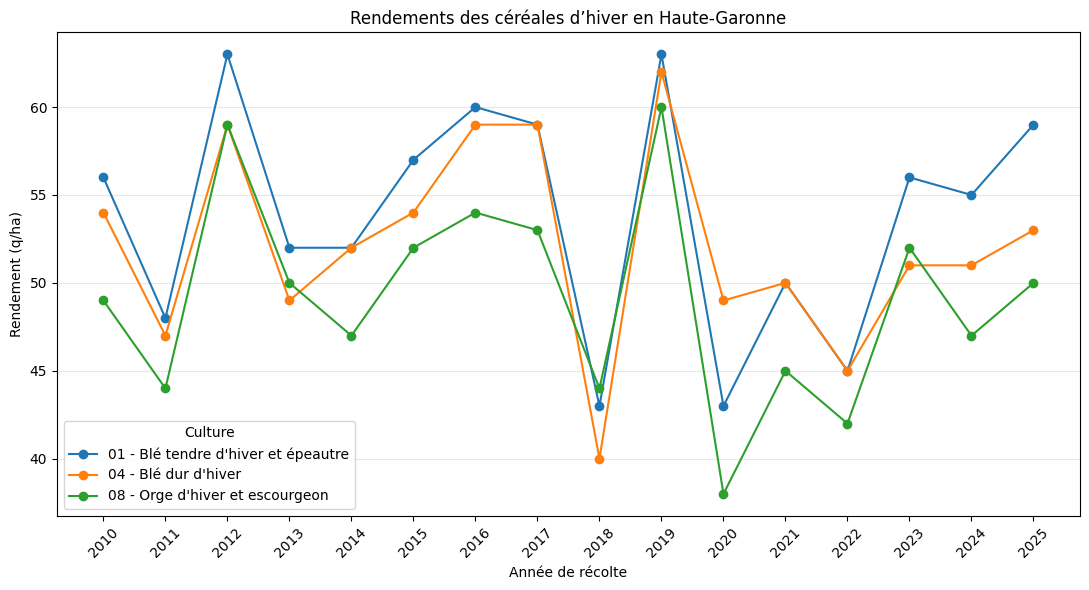

In [12]:
# OBJECTIF
# Comparer l’évolution des rendements des trois cultures.


# ÉTAPE 1 — Importer l’outil de création des graphiques
import matplotlib.pyplot as plt


# ÉTAPE 2 — Créer la figure
fig, ax = plt.subplots(figsize=(11, 6))


# ÉTAPE 3 — Tracer une courbe pour chaque culture
for culture, tableau_culture in rendements.groupby("culture"):
    ax.plot(
        tableau_culture["annee"],
        tableau_culture["rendement_q_ha"],
        marker="o",
        label=culture
    )


# ÉTAPE 4 — Ajouter le titre et les noms des axes
ax.set_title("Rendements des céréales d’hiver en Haute-Garonne")
ax.set_xlabel("Année de récolte")
ax.set_ylabel("Rendement (q/ha)")


# ÉTAPE 5 — Afficher les années, la grille et la légende
ax.set_xticks(range(2010, 2026))
ax.tick_params(axis="x", labelrotation=45)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Culture")


# ÉTAPE 6 — Ajuster la présentation et afficher
fig.tight_layout()
plt.show()

Les campagnes 2018, 2020 et 2022 présentent des rendements relativement faibles pour les trois cultures étudiées. Cette variation commune suggère d’examiner des facteurs partagés, notamment les conditions météorologiques. Le graphique seul ne permet pas d’attribuer ces faibles rendements à la sécheresse.

In [13]:
# OBJECTIF
# Calculer les écarts à la moyenne de chaque culture.
# Examiner les campagnes 2018, 2020 et 2022.


# ÉTAPE 1 — Copier le tableau pour conserver les rendements d’origine
analyse_rendements = rendements.copy()


# ÉTAPE 2 — Calculer la moyenne de chaque culture
# transform() associe cette moyenne à chaque ligne de la culture.
analyse_rendements["moyenne_q_ha"] = (
    analyse_rendements.groupby("culture")["rendement_q_ha"]
    .transform("mean")
)


# ÉTAPE 3 — Calculer l’écart en q/ha
analyse_rendements["ecart_q_ha"] = (
    analyse_rendements["rendement_q_ha"]
    - analyse_rendements["moyenne_q_ha"]
)


# ÉTAPE 4 — Calculer l’écart en pourcentage de la moyenne
analyse_rendements["ecart_pct"] = (
    analyse_rendements["ecart_q_ha"]
    / analyse_rendements["moyenne_q_ha"]
    * 100
)


# ÉTAPE 5 — Sélectionner les trois campagnes repérées
annees_a_examiner = [2018, 2020, 2022]

campagnes_selectionnees = analyse_rendements[
    analyse_rendements["annee"].isin(annees_a_examiner)
]


# ÉTAPE 6 — Afficher les résultats avec deux décimales
display(
    campagnes_selectionnees[
        [
            "culture",
            "annee",
            "rendement_q_ha",
            "moyenne_q_ha",
            "ecart_q_ha",
            "ecart_pct"
        ]
    ].round(2)
)

,culture,annee,rendement_q_ha,moyenne_q_ha,ecart_q_ha,ecart_pct
8,01 - Blé tendre d'hiver et épeautre,2018,43.0,53.81,-10.81,-20.09
10,01 - Blé tendre d'hiver et épeautre,2020,43.0,53.81,-10.81,-20.09
12,01 - Blé tendre d'hiver et épeautre,2022,45.0,53.81,-8.81,-16.38
24,04 - Blé dur d'hiver,2018,40.0,52.12,-12.12,-23.26
26,04 - Blé dur d'hiver,2020,49.0,52.12,-3.12,-6.00
28,04 - Blé dur d'hiver,2022,45.0,52.12,-7.12,-13.67
40,08 - Orge d'hiver et escourgeon,2018,44.0,49.12,-5.12,-10.43
42,08 - Orge d'hiver et escourgeon,2020,38.0,49.12,-11.12,-22.65
44,08 - Orge d'hiver et escourgeon,2022,42.0,49.12,-7.12,-14.50


Parmi les campagnes 2018, 2020 et 2022, le blé tendre présente son écart le plus négatif en 2018 et 2020, le blé dur en 2018 et l’orge d’hiver en 2020. En 2022, les trois cultures affichent des rendements inférieurs à leur moyenne 2010–2025, avec des écarts compris entre −13,67 % et −16,38 %. Ces différences invitent à examiner les conditions météorologiques selon les périodes du cycle de chaque culture. Elles ne permettent pas, à elles seules, d’attribuer les faibles rendements à la sécheresse.